In [29]:
import numpy as np
import matplotlib.pyplot as plt
 
"""
Simple 0D combustion chamber model using Euler integration.

Scenario: Engine startup — chamber pressurizes from ambient 
to operating pressure as propellants start flowing in.

Chamber state variables:
- P: chamber pressure (bar)
- T: chamber temperature (K)

Governing equations (simplified):
- dP/dt = (mdot_in - mdot_out) * R * T / (V * M)
- mdot_out = Cd * At * P / sqrt(T)  ← choked nozzle flow

This is the simplest physically-grounded 0D model.
"""

'\nSimple 0D combustion chamber model using Euler integration.\n\nScenario: Engine startup — chamber pressurizes from ambient \nto operating pressure as propellants start flowing in.\n\nChamber state variables:\n- P: chamber pressure (bar)\n- T: chamber temperature (K)\n\nGoverning equations (simplified):\n- dP/dt = (mdot_in - mdot_out) * R * T / (V * M)\n- mdot_out = Cd * At * P / sqrt(T)  ← choked nozzle flow\n\nThis is the simplest physically-grounded 0D model.\n'

In [30]:

# Constants
R = 8.314          # J/mol·K universal gas constant
M = 0.022          # kg/mol — molecular mass of combustion products
V = 0.05           # m³ — combustion chamber volume
Cd = 0.95          # nozzle discharge coefficient
At = 0.0117          # m² — throat area

# At steady state: mdot_in = mdot_out
# 358 = Cd × At × P × choked_const / sqrt(T)
# Solve for At given P=350 bar:
'''
At = 358 * sqrt(3500) / (0.97 × 350e5 × 0.0334)
        ≈ 0.0117 m²  
'''


'\nAt = 358 * sqrt(3500) / (0.97 × 350e5 × 0.0334)\n        ≈ 0.0117 m²  \n'

In [31]:
# Initial conditions
P0 = 1.0           # bar — starts at atmospheric
T_chamber = 3500   # K — combustion temperature (constant simplified)


# Simulation parameters
dt = 0.001         # seconds — timestep
t_end = 2.0        # seconds — simulate 2 second startup
t = np.arange(0, t_end, dt)

In [32]:
R_specific = 8.314 / 0.022   # = 377.9 J/kg·K
gamma = 1.2
choked_const = np.sqrt(gamma / R_specific) * \
               (2/(gamma+1))**((gamma+1)/(2*(gamma-1)))

# Propellant flow schedule (valve opens gradually) simplified
def mdot_in(time):
    """Mass flow rate into chamber — ramps up over 0.5 seconds"""
    ramp = min(time/0.5, 1.0)       # 0 to 1 over 0.5 seconds
    return ramp * 358.0             # kg/s nominal total flow (78 + 280) rate

def mdot_out(P_bar, T):
    """Mass flow through nozzle — choked flow"""
    P_pa = P_bar * 1e5              # convert bar to Pa
    return Cd * At * P_pa * choked_const / np.sqrt(T)
    # Drops the γ terms and uses 0.001 as a lumped constant to approximate them. It's a teaching simplification, not rigorous engineering.


# # Propellant flow schedule (valve opens gradually)
# def mdot_in(time):
#     """Mass flow rate into chamber — ramps up over 0.5 seconds"""
#     ramp = min(time / 0.5, 1.0)  # 0 to 1 over 0.5 seconds
#     return ramp * 358.0           # kg/s nominal total flow (78 + 280)

# def mdot_out(P_bar, T):
#     """Mass flow through nozzle — choked flow"""
#     P_pa = P_bar * 1e5           # convert bar to Pa
#     return Cd * At * P_pa / np.sqrt(T) * 0.001  # simplified
#     # Drops the γ terms (fudge factor) and uses 0.001 as a lumped constant to approximate them. It's a teaching simplification, not rigorous engineering.



    '''
    Flow rate
    (kg/s)
    358 |          _____________
        |         /
    179 |        /
        |       /
    0 |______/
        0    0.5    1.0    2.0   time (s)
            ↑
        fully open
    '''

In [33]:
# Euler integration
P = np.zeros(len(t))
P[0] = P0

for i in range(len(t) - 1):
    # Current state
    P_current = P[i]
    
    # Mass flows
    flow_in  = mdot_in(t[i])
    flow_out = mdot_out(P_current, T_chamber)
    
    # ODE: dP/dt from ideal gas + mass conservation
    dP_dt = (flow_in - flow_out) * R_specific * T_chamber / (V * 1e5)
    
    # Euler step
    P[i+1] = P_current + dt * dP_dt
    
    # Physical constraint — can't go below zero
    P[i+1] = max(P[i+1], 0.0)

    

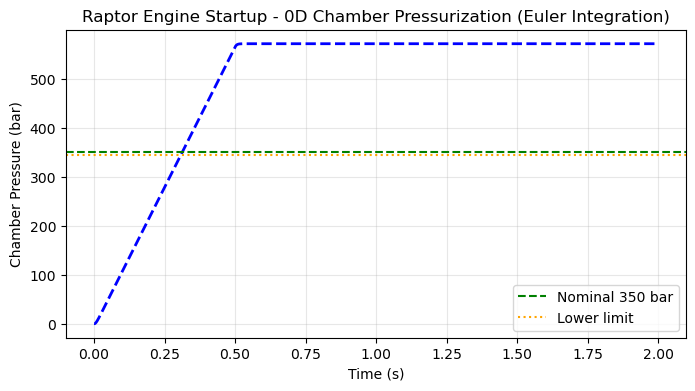

In [34]:
plt.figure(figsize=(8,4))
plt.plot(t,P, 'b--', linewidth=2)
plt.axhline(350, color = 'g', linestyle='--', label='Nominal 350 bar')
plt.axhline(345, color = 'orange', linestyle=':', label='Lower limit')

plt.title('Raptor Engine Startup - 0D Chamber Pressurization (Euler Integration)')
plt.xlabel('Time (s)')
plt.ylabel('Chamber Pressure (bar)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [35]:
steady_state_P = P[-1]
startup_time = t[np.argmax(P>340)]
print(f"Steady state pressure: {steady_state_P:.1f} bar")
print(f"Time to 340 bar:       {startup_time:.3f} s")

Steady state pressure: 571.2 bar
Time to 340 bar:       0.304 s
